# Discussion

This notebook is where we investigate and experiment with ideas for improving the current modeling pipeline. We explore hypotheses, run experiments, inspect results, and let what we learn guide what to try next.

## Label Propagation Diagnostics

Our current pipeline combines feature imputation, graph-based label propagation, and classification with HistGradientBoostingClassifier. The pipeline runs end-to-end, but its cross-validation cost is substantially worse per user than the competition baseline (roughly $68 per validation user versus $38.5 per baseline test user).

Part of this gap is likely explained by a population mismatch rather than model weakness: our labeled data, and therefore every cross-validation fold, consists entirely of manually reviewed ("flagged") users, since `is_cheating` is only observed when `high_conf_clean` is absent. The competition test set, by contrast, does not carry the `high_conf_clean` column at all, suggesting it spans the general population rather than only flagged users. Our validation is therefore estimating `P(cheat | flagged)` on a deliberately hard subpopulation, while the baseline cost is likely averaged over a much easier general population. We separately confirmed this gap is not caused by label propagation or the resolver: training on the originally labeled data alone, with propagation and resolution both disabled, produces cross-validation costs in the same range as every other configuration tried.

That said, label propagation remains worth validating in its own right. Of the pipeline's components, we place the most trust in the classifier and imputer, both of which rely on well-tested scikit-learn functionality applied in a fairly standard way. Label propagation is comparatively bespoke: it required a custom graph construction, a nonstandard use of scikit-learn's `LabelPropagation` via a precomputed kernel, and connected-component filtering logic we wrote ourselves. It is the component most likely to contain either a subtle bug or genuinely weak signal, independent of the score gap discussed above.

To validate it, we will hide labels from held-out users, run propagation using the remaining labeled users and the social graph, and compare the propagated labels with the known ground truth. This will tell us whether the graph is actually providing useful label information and whether the propagation procedure is reliable enough to build upon, before we invest further in improving or relying on it.

**Results.** Label propagation achieved a balanced accuracy of **0.6289** across the five folds, with highly consistent performance (**std = 0.0055**). Since 0.5 corresponds to chance-level performance for balanced accuracy, this indicates that the social graph provides **meaningful but limited predictive signal** for identifying cheating, supporting further use of graph information while suggesting that label propagation alone is unlikely to be sufficient as a predictor. This result is plausible given the nature of the graph: it represents referral relationships, which can reasonably be expected to introduce some association with cheating behavior, but a referral link does not necessarily imply strong similarity in whether a user is cheating. The observed performance is therefore consistent with the graph carrying useful but relatively weak signal. This suggests that **user features should be incorporated into the labeling process for currently unlabeled nodes**, complementing the information provided by the social graph.

## Enhancing Pseudo-Labeling

Our goal is to improve the quality of pseudo-labeling for the currently unlabeled population. We therefore investigate whether combining graph-based label propagation with feature-based classification can improve upon label propagation alone.

The key question is how to combine these sources of information in a way that exploits their complementary signals while preserving a valid evaluation procedure.

### Gated prediction

Label propagation exploits the social graph but does not use the feature information available to the classifier. We therefore consider a heuristic combination of graph-based and feature-based predictions, with the relative weight assigned according to how likely a user is to belong to the flagged population.

Let `F(x)` denote the probability that a user with features `x` is flagged, `CF(x)` the feature-based cheating prediction, and `LP(x)` the graph-based prediction. We define the gated prediction as

$$
G(x) = F(x)\,CF(x) + (1-F(x))\,LP(x).
$$

The flagger `F(x)` therefore acts as a gate between the two predictors: users more likely to be flagged receive greater weight from the feature-based classifier, while users less likely to be flagged rely more heavily on label propagation.

This formulation is a heuristic rather than a probability-theoretic decomposition. Although it resembles the law of total probability, `CF(x)` and `LP(x)` do not represent the corresponding conditional probabilities required for such an interpretation.

The three components also have different data-access and leakage considerations. `F(x)` predicts the observed flagged status and does not depend on the user's `is_cheating` label. `CF(x)` and `LP(x)`, however, both use `is_cheating` labels and must therefore be evaluated without access to the true labels of the users whose predictions are being assessed.

### Flagger

The flagger `F(x)` predicts whether a user belongs to the flagged population, using the same feature set available to the cheating classifier. Unlike `CF(x)` and `LP(x)`, its target is the observed flagged status rather than `is_cheating`. Since flagged status is known for the entire population, training `F(x)` does not require access to, or masking of, the `is_cheating` labels.

**Data Leakage.** Using the same features for `F(x)` and `CF(x)` does not introduce data leakage: the two models predict different targets. The relevant leakage concern for `F(x)` is therefore distinct from that of the components predicting `is_cheating`.

**The Flagger as an Experimental Testbed.** Because flagged status is observed for the entire population, `F(x)` gives us a fully supervised classification problem on the same tabular features as the cheating classifier, providing a controlled testbed for comparing preprocessing choices and learning algorithms, with data, folds, and metric held fixed. A first test already illustrates its value: HGBDT reached 0.9233 ± 0.0009 balanced accuracy without imputation, compared with 0.9219 ± 0.0007 with our current imputer. More broadly, this gives us a fast, clean way to assess how well different algorithms and preprocessing choices can extract predictive signal from our tabular data before introducing them into the harder, partially-labeled `is_cheating` task.

**Missingness as Signal.** The challenge explicitly warns that NaN values are informative, because some signals are only available for certain candidates. Our experiments with the flagger confirmed the practical importance of this design choice. Both HGBDT and Random Forest performed slightly better when given the original missing values than when processed by our `IterativeImputer`. In this case, the models' native handling of missing values allows them to exploit the missingness patterns directly, whereas imputation can remove part of that signal. This suggests that, for models capable of handling NaNs natively, imputation may be unnecessary and could discard useful information. Rather than automatically preprocessing missing values, we should therefore treat missingness as a potentially predictive aspect of the data and let the learning algorithm handle it when appropriate.

**Reconstructing the Selection Mechanism.** The flagger achieves remarkably strong generalization performance, with balanced accuracy around 0.92 across different tree-based models. Importantly, there is no ground truth for the flagging mechanism itself. Instead, we are effectively trying to reverse engineer that mechanism from the available features. The fact that the observed flagging behavior is so predictable suggests that the features contain a strong and reproducible signature of how candidates were selected into the flagged population. This is precisely what `F(x)` is intended to capture as the gate between `CF(x)` and `LP(x)`.

### Testing the flagger

**Test Setup.** We compare four model families with different inductive biases: HistGradientBoosting, Random Forest, Support Vector Classification, and Logistic Regression. For the tree-based models, we evaluate three preprocessing variants: `IterativeImputer`, `SimpleImputer`, and no imputation, while simultaneously tuning their hyperparameters using randomized search. For SVC and Logistic Regression, which cannot natively handle missing values, we compare the two imputation methods and additionally test the sensitivity of SVC to `C` and `gamma`. For Logistic Regression, we also investigate polynomial features of degree two and tune the regularization parameter `C`. All experiments are evaluated using nested cross-validation.

**Results.**

| Model               | Configuration                                   | Balanced accuracy |    Std | Time (s) |
| ------------------- | ----------------------------------------------- | ----------------: | -----: | -------: |
| HGBDT               | Iterative imputation + Parameter search         |            0.9232 | 0.0009 |    404.5 |
| HGBDT               | Simple imputation + Parameter search            |            0.9244 | 0.0005 |    200.8 |
| HGBDT               | No imputation + Parameter search                |            0.9245 | 0.0008 |    211.5 |
| Random Forest       | Iterative imputation + Parameter search         |            0.9228 | 0.0003 |   3165.4 |
| Random Forest       | Simple imputation + Parameter search            |            0.9238 | 0.0002 |   2569.9 |
| Random Forest       | No imputation + Parameter search                |            0.9241 | 0.0009 |   3176.0 |
| SVC                 | Iterative imputation                            |            0.9150 | 0.0005 |   1343.8 |
| SVC                 | Simple imputation                               |            0.9150 | 0.0004 |   1713.9 |
| SVC                 | Iterative imputation + Lower C                  |            0.9114 | 0.0005 |   2505.5 |
| SVC                 | Iterative imputation + Higher C                 |            0.9153 | 0.0009 |   5124.1 |
| Logistic Regression | Iterative imputation                            |            0.8558 | 0.0010 |     23.0 |
| Logistic Regression | Simple imputation                               |            0.8592 | 0.0007 |      7.2 |
| Logistic Regression | Iterative imputation + poly features (deg=2)    |            0.9078 | 0.0009 |     48.6 |
| Logistic Regression | Simple imputation + poly features (deg=2)       |            0.9059 | 0.0010 |     26.5 |
| Logistic Regression | Iterative imputation + poly features + C search |            0.9078 | 0.0010 |   1293.5 |
| MLPClassifier       | Iterative imputation                            |            0.9185 | 0.0006 |    138.9 |
| MLPClassifier       | Simple imputation                               |            0.9174 | 0.0014 |    104.1 |
| MLPClassifier       | Iterative imputation + 2 hidden layers          |            0.9099 | 0.0019 |    948.9 |

The results show that tree-based models perform best, with `HGBDT` and `Random Forest` reaching around 0.924–0.925 balanced accuracy, while `SVC` and `MLPClassifier` achieve around 0.915–0.919. Baseline `Logistic Regression` performs substantially worse (0.856), but polynomial features raise it to 0.908, showing that nonlinear interactions capture substantial additional signal. For `HGBDT` and `Random Forest`, iterative imputation is actually worse than simple or native missing-value handling, while the more complex two-hidden-layer `MLPClassifier` also performs worse than the simpler network. Overall, these experiments provide no evidence that more sophisticated imputation or model complexity improves flagging prediction.

**Validation Curve.**

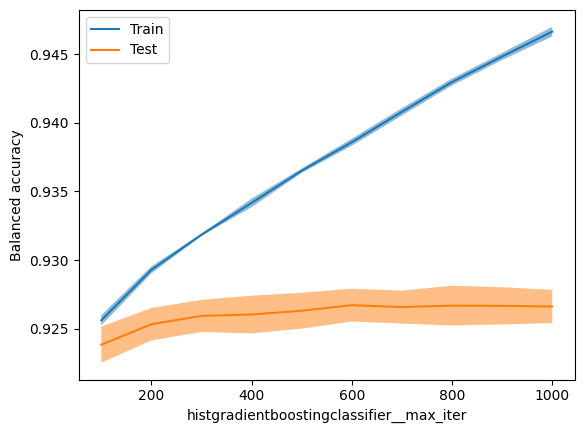

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, ValidationCurveDisplay
from sklearn.pipeline import make_pipeline

N_SPLITS = 5
RANDOM_STATE = 42

data_train = pd.read_csv("../data/train.csv")
data_train["flagged"] = data_train["high_conf_clean"].isna().astype(int)
data_train = data_train.sample(frac=1.0, random_state=RANDOM_STATE)
target_name = "flagged"
target_train = data_train[target_name]
data_train = data_train.drop(columns=[target_name])
data_train = data_train.drop(
    columns=["high_conf_clean", "is_cheating", "user_hash"]
)

cv = StratifiedKFold(
    N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

pipeline = make_pipeline(
    HistGradientBoostingClassifier(
        early_stopping=False,
    ),
)

ValidationCurveDisplay.from_estimator(
    pipeline,
    data_train,
    target_train,
    param_name="histgradientboostingclassifier__max_iter",
    param_range=range(100, 1001, 100),
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1,
)

plt.show()

**Insights.**

**(1) The flagger is highly trustworthy as a reconstruction of the original flagging mechanism.**

With balanced accuracy of approximately 0.925, `F(x)` generalizes extremely well at predicting whether the original mechanism would have flagged a user. This is precisely what we need from the gate. The remaining disagreement does not necessarily mean that `F(x)` is wrong about who *should* be flagged, since that underlying truth is unobservable.

**(2) Tree-based models are exceptionally well suited to our feature space.**

Decision-tree-based methods achieved the strongest performance while remaining computationally practical. HGBDT and Random Forest both reached approximately 0.925 balanced accuracy, substantially outperforming Logistic Regression and SVC. The large gap between tree-based and linear models suggests that our data contains substantial nonlinear structure and feature interactions that tree-based models can exploit effectively. The consistently high performance across folds, with a standard deviation of approximately 0.001, further indicates that this advantage is stable rather than driven by a particular subset of the data.

**(3) Native missing-value handling is preferable for tree-based models, although `IterativeImputer` preserves most of the predictive signal.**

Both HGBDT and Random Forest performed slightly better without our `IterativeImputer`, consistent with the possibility that missingness patterns themselves carry useful information that explicit imputation does not fully preserve. At the same time, the performance gap is small, indicating that `IterativeImputer` retains most of the predictive information relevant to the flagger. Thus, the imputer is not failing; it is simply unnecessary when the learning algorithm can exploit missing values directly. Runtime tells a related story: `IterativeImputer` is by far the slowest option, while simple imputation is consistently faster than native NaN handling at essentially comparable accuracy. This distinction is important for models such as SVC and Logistic Regression, which cannot natively handle NaNs and therefore depend on imputation. It also motivates our next experiment: rather than asking whether imputation can outperform native missing-value handling, we ask whether a more robust and stable imputation method such as `miceforest` can improve upon `IterativeImputer` where imputation is actually required.

**(4) `F(x)` doubles as a diagnostic for the population-mismatch problem.**

Because `F(x)` reconstructs the original flagging decision with approximately 0.925 balanced accuracy, it can be applied beyond the labeled population to measure how "flag-like" other populations look. For instance, applying it to the test set or the unlabeled train population gives us a quantitative measure of how closely they resemble the flagged population from which our validation data is drawn. This turns the population-mismatch concern from a qualitative caveat into something measurable, and offers a concrete next step for characterizing the CV/test gap.

---

Taken together, these findings give us a strong basis for using `F(x)` as the gate: the original flagging mechanism is highly predictable from the available features, tree-based learning is particularly well matched to the feature space, and native missing-value handling provides the best performance where available. At the same time, `IterativeImputer` performs well enough to justify investigating whether a more mature imputation method can improve the models that depend on it.

### Testing imputation in isolation

| Model                            | Imputation | Balanced accuracy |    Std | Time (s) |
| -------------------------------- | ---------- | ----------------: | -----: | -------: |
| `HistGradientBoostingClassifier` | Iterative  |            0.9219 | 0.0006 |     15.3 |
| `HistGradientBoostingClassifier` | MICEForest |            0.9058 | 0.0011 |    943.8 |

**Discussion.** `HistGradientBoostingClassifier` performs substantially better with `IterativeImputer` than with `miceforest`, while also running an order of magnitude faster. Increasing `miceforest`'s iterations from 5 to 20 left the score unchanged while roughly quadrupling runtime, ruling out undercooked convergence as an explanation for its weaker result. Combined with the earlier finding that native missing-value handling beats `IterativeImputer` itself, this reinforces (3): for this dataset, simpler or no explicit imputation outperforms more elaborate alternatives.

### `CF(x)`

`CF(x)` was proposed as the feature-based component of the gated architecture

$$
G(x)=F(x)CF(x)+(1-F(x))LP(x),
$$

predicting cheating from features on labeled users. Since `F(x)` achieved around 0.925 balanced accuracy, the initial idea was that a sufficiently strong `CF(x)` could provide the complementary prediction needed by the gate.

**Testing across model families.** We tested `CF(x)` with HGBDT, Random Forest, SVC, Logistic Regression, and MLP on both the full labeled population and labeled users outside the social graph:

| Model |    Full labeled |   Outside graph |
| ----- | --------------: | --------------: |
| HGBDT | 0.7278 ± 0.0025 | 0.7965 ± 0.0039 |
| RF    | 0.7211 ± 0.0031 | 0.7880 ± 0.0042 |
| SVC   | 0.6926 ± 0.0031 | 0.7711 ± 0.0017 |
| LR    | 0.7043 ± 0.0020 | 0.7722 ± 0.0054 |
| MLP   | 0.7174 ± 0.0051 | 0.7750 ± 0.0038 |

Despite the substantially different model families, results on the full labeled population remained in the same general range. Restricting to labeled users outside the graph produced a consistent, substantial improvement across every model, indicating that the difficulty was strongly associated with the population being modeled rather than with the choice of model.

**Isolating the graph direction.** We next used HGBDT to separate the two roles in the directed graph. Referrers and referred users were separately excluded from the full labeled population:

| Population   |           HGBDT |
| ------------ | --------------: |
| Full labeled | 0.7278 ± 0.0025 |
| No referrers | 0.7283 ± 0.0029 |
| No referred  | 0.7931 ± 0.0041 |

Removing referrers has essentially no effect. Removing referred users recovers nearly the entire improvement seen when excluding the whole graph. The difficulty is therefore associated much more strongly with the referred population than with graph membership in general.

**Direction of the graph.** This asymmetry suggests that the graph may contain directional information that an undirected representation discards. Since our current label propagation treats edges symmetrically, we should first test the simplest directed alternative: label propagation on the directed graph.

**Conclusion.** These experiments show that the features contain useful information about cheating, but that feature-only classification is substantially weaker on the referred population. This makes `CF(x)` unsuitable as the central component of the original gated architecture. At the same time, the experiments revealed a useful distinction between populations. Rather than predicting graph membership with `F(x)` and using it as a learned gate, we can use the actual graph structure to determine the prediction regime: a graph-based classifier for users in the graph, and a feature-based classifier for users outside it. This removes the need for the original gated architecture and shifts the focus to improving the graph-based labeling method.